In [1]:
!pip install optuna torch torchvision seaborn matplotlib scikit-learn pillow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.2 MB/s eta 0:00:00


In [2]:
# Cell 2: Import semua modul
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix
)
from sklearn.model_selection import StratifiedShuffleSplit

import optuna

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(" Semua library berhasil diimport")

 Semua library berhasil diimport


In [3]:
# Cell 3: Set seed & device
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  Device: {device}")

LABELS = [chr(i + ord('a')) for i in range(26)]
NUM_CLASSES = 26

# Hyperparameter tuning dengan Optuna
N_TRIALS = 10
TUNING_EPOCHS = 5
EARLY_STOP_TUNING = 4

# Training final
FINAL_EPOCHS = 30
EARLY_STOP_FINAL = 7

print(f" Konfigurasi:")
print(f"   Kelas: {NUM_CLASSES} ({', '.join(LABELS)})")
print(f"   Trial Optuna: {N_TRIALS}")
print(f"   Maks epoch final: {FINAL_EPOCHS}")

  Device: cuda
 Konfigurasi:
   Kelas: 26 (a, b, c, d, e, f, g, h, i, j, k, l, m, n, o, p, q, r, s, t, u, v, w, x, y, z)
   Trial Optuna: 10
   Maks epoch final: 30


In [4]:
# Cell 5: Fungsi load data
def load_and_prepare_data():
    train_files = [
        "emnist_lowercase_train_balanced.npz",
        "dataset_abjad_custom_train.npz"
    ]
    test_files = [
        "emnist_lowercase_test_balanced.npz",
        "dataset_abjad_custom_test.npz"
    ]

    def load_npz_files(file_list, name):
        print(f"\n {name} Data...")
        X_list, y_list = [], []
        for file in file_list:
            try:
                data = np.load(file)
                keys = data.files
                # Asumsikan kunci 'x' untuk gambar, 'y' untuk label (sesuaikan jika beda)
                if 'x' in keys and 'y' in keys:
                    X_raw, y_raw = data['x'], data['y']
                elif len(data[keys[0]].shape) > 1:  # fallback
                    X_raw, y_raw = data[keys[0]], data[keys[1]]
                else:
                    X_raw, y_raw = data[keys[1]], data[keys[0]]
                X_list.append(X_raw)
                y_list.append(y_raw)
                print(f"   ✓ {file}: {len(X_raw):,} sampel")
            except FileNotFoundError:
                print(f"   {file} tidak ditemukan")
        if not X_list:
            raise FileNotFoundError("Dataset tidak ditemukan, pastikan file .npz ada di direktori yang sama")
        return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

    X_train, y_train = load_npz_files(train_files, "TRAIN")
    X_test, y_test = load_npz_files(test_files, "TEST")

    # Normalisasi ke [0,1] dan reshape ke (N, 1, 28, 28)
    X_train = X_train.astype(np.float32) / 255.0
    X_test = X_test.astype(np.float32) / 255.0
    y_train = y_train.astype(np.int64)
    y_test = y_test.astype(np.int64)

    if len(X_train.shape) == 2:
        X_train = X_train.reshape(-1, 1, 28, 28)
        X_test = X_test.reshape(-1, 1, 28, 28)
    elif X_train.shape[-1] == 28 and len(X_train.shape) == 3:
        X_train = X_train.reshape(-1, 1, 28, 28)
        X_test = X_test.reshape(-1, 1, 28, 28)

    print(f"\n✅ Dataset dimuat:")
    print(f"   Train: {len(X_train):,} | Test: {len(X_test):,}")
    print(f"   Shape: {X_train.shape}")
    print(f"   Kelas unik: {len(np.unique(y_train))} (a-z)")
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_and_prepare_data()


 TRAIN Data...
   ✓ emnist_lowercase_train_balanced.npz: 49,296 sampel
   ✓ dataset_abjad_custom_train.npz: 6,240 sampel

 TEST Data...
   ✓ emnist_lowercase_test_balanced.npz: 8,242 sampel
   ✓ dataset_abjad_custom_test.npz: 260 sampel

✅ Dataset dimuat:
   Train: 55,536 | Test: 8,502
   Shape: (55536, 1, 28, 28)
   Kelas unik: 26 (a-z)


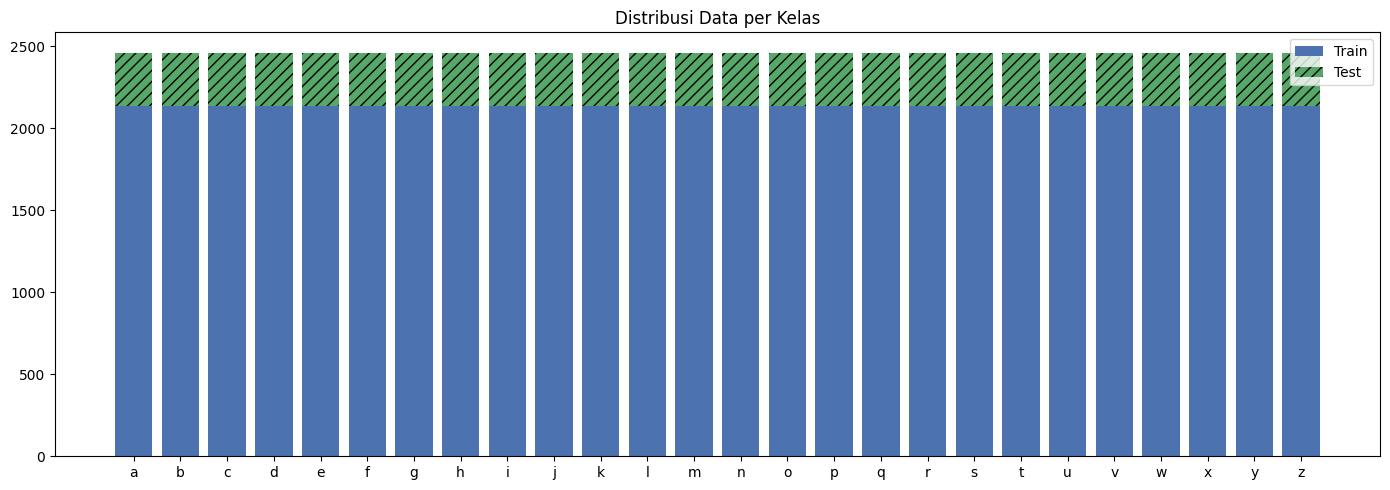

In [5]:
# Cell 6: Visualisasi distribusi
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14,5))
train_vals = [train_counts.get(i,0) for i in range(26)]
test_vals = [test_counts.get(i,0) for i in range(26)]
ax.bar(LABELS, train_vals, label='Train', color='#4C72B0')
ax.bar(LABELS, test_vals, bottom=train_vals, label='Test', color='#55A868', hatch='///')
ax.set_title("Distribusi Data per Kelas")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Cell 7: Split data train -> train + validation (85:15) dari numpy asli
full_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
val_size = int(0.15 * len(X_train))
train_size = len(X_train) - val_size

train_dataset_raw, val_dataset_raw = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Ekstrak numpy untuk digunakan nanti
X_train_np = np.array([train_dataset_raw[i][0].numpy() for i in range(len(train_dataset_raw))])
y_train_np = np.array([train_dataset_raw[i][1].item() for i in range(len(train_dataset_raw))])
X_val_np = np.array([val_dataset_raw[i][0].numpy() for i in range(len(val_dataset_raw))])
y_val_np = np.array([val_dataset_raw[i][1].item() for i in range(len(val_dataset_raw))])

print(f" Data Split (random 85:15):")
print(f"   Train: {len(X_train_np):,} | Val: {len(X_val_np):,} | Test: {len(X_test):,}")

 Data Split (random 85:15):
   Train: 47,206 | Val: 8,330 | Test: 8,502


In [7]:
# Cell 8: Definisi model AlexNet pretrained
def create_alexnet_pretrained(num_classes=26, dropout_rate=0.5):
    model = models.alexnet(pretrained=True)
    model.classifier = nn.Sequential(
        nn.Dropout(dropout_rate),
        nn.Linear(9216, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout_rate),
        nn.Linear(4096, 4096),
        nn.ReLU(inplace=True),
        nn.Linear(4096, num_classes),
    )
    return model

# Verifikasi
dummy = torch.randn(1, 3, 224, 224)
test_model = create_alexnet_pretrained(num_classes=26, dropout_rate=0.5)
with torch.no_grad():
    out = test_model(dummy)
print(f" AlexNet pretrained siap: input {dummy.shape} → output {out.shape}")
print(f"   Jumlah parameter: {sum(p.numel() for p in test_model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 174MB/s]


 AlexNet pretrained siap: input torch.Size([1, 3, 224, 224]) → output torch.Size([1, 26])
   Jumlah parameter: 57,110,362


In [8]:
# Cell 9: Fungsi evaluasi
def evaluate_model(model, data_loader, loss_fn=None):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            if loss_fn:
                total_loss += loss_fn(outputs, labels).item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    result = {'accuracy': acc, 'f1_score': f1, 'predictions': np.array(all_preds), 'labels': np.array(all_labels)}
    if loss_fn:
        result['loss'] = total_loss / len(data_loader)
    return result

In [9]:
# Cell 10: Transform TANPA augmentasi
def get_transforms():
    # Hanya resize + konversi grayscale ke 3-channel + normalisasi ImageNet
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(224),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

In [10]:
# Cell 11: Dataset helper
def create_dataset_from_np(X, y):
    class NumpyDataset(torch.utils.data.Dataset):
        def __init__(self, X, y, transform):
            self.X = X
            self.y = y
            self.transform = transform
        def __len__(self):
            return len(self.X)
        def __getitem__(self, idx):
            img = self.X[idx].squeeze(0)  # (28,28)
            label = self.y[idx]
            img = self.transform(img)
            return img, label
    return NumpyDataset(X, y, get_transforms())

In [11]:
# Cell 12: Objective function untuk Optuna (dengan subset)
def alexnet_objective(trial):
    # === Subset untuk tuning cepat ===
    subset_size = min(5000, len(X_train_np))
    X_train_sub = X_train_np[:subset_size]
    y_train_sub = y_train_np[:subset_size]

    val_subset_size = min(2000, len(X_val_np))
    X_val_sub = X_val_np[:val_subset_size]
    y_val_sub = y_val_np[:val_subset_size]
    # =================================

    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.3, 0.7)
    batch_size = trial.suggest_categorical("batch_size", [128, 256])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    optim_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])
    momentum = trial.suggest_float("momentum", 0.8, 0.99) if optim_name == "SGD" else None

    train_dataset = create_dataset_from_np(X_train_sub, y_train_sub)
    val_dataset = create_dataset_from_np(X_val_sub, y_val_sub)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    model = create_alexnet_pretrained(num_classes=NUM_CLASSES, dropout_rate=dropout).to(device)

    if optim_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    loss_fn = nn.CrossEntropyLoss()

    best_f1 = 0
    no_improve = 0

    for epoch in range(TUNING_EPOCHS):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        val_res = evaluate_model(model, val_loader)
        val_f1 = val_res['f1_score']
        scheduler.step(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= EARLY_STOP_TUNING:
            break

    return best_f1

In [12]:
# Cell 13: Jalankan Optuna
print("\n Memulai Bayesian Optimization dengan Optuna")
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(alexnet_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n Best hyperparameters ditemukan:")
for k, v in study.best_params.items():
    print(f"   {k}: {v}")
print(f"   Best validation F1 macro: {study.best_value:.4f}")


 Memulai Bayesian Optimization dengan Optuna


  0%|          | 0/10 [00:00<?, ?it/s]


 Best hyperparameters ditemukan:
   lr: 0.0001329291894316216
   dropout: 0.6802857225639665
   batch_size: 128
   weight_decay: 2.9380279387035354e-06
   optimizer: Adam
   Best validation F1 macro: 0.9154


In [13]:
# Cell 14: Siapkan data final (train+val gabungan untuk training, test tetap)
best_params = study.best_params

# Gabungkan train & val asli (numpy)
X_full_train = np.concatenate([X_train_np, X_val_np])
y_full_train = np.concatenate([y_train_np, y_val_np])

# Dataset tanpa augmentasi
full_train_dataset = create_dataset_from_np(X_full_train, y_full_train)
test_dataset = create_dataset_from_np(X_test, y_test)

# Buat validation kecil dari full_train_dataset untuk monitoring (tanpa augmentasi)
full_train_len = len(full_train_dataset)
val_len = int(0.15 * full_train_len)
train_len = full_train_len - val_len
train_sub, val_sub = random_split(full_train_dataset, [train_len, val_len],
                                  generator=torch.Generator().manual_seed(SEED))

train_loader_monitor = DataLoader(train_sub, batch_size=best_params['batch_size'],
                                  shuffle=True, num_workers=2)
val_loader_monitor = DataLoader(val_sub, batch_size=best_params['batch_size'],
                                shuffle=False, num_workers=2)

# Test loader
test_loader_final = DataLoader(test_dataset, batch_size=best_params['batch_size'],
                               shuffle=False, num_workers=2)

In [14]:
# Cell 15: Inisialisasi model final
model = create_alexnet_pretrained(num_classes=NUM_CLASSES, dropout_rate=best_params['dropout']).to(device)

if best_params['optimizer'] == 'Adam':
    optimizer = optim.Adam(model.parameters(), lr=best_params['lr'],
                           weight_decay=best_params['weight_decay'])
else:
    optimizer = optim.SGD(model.parameters(), lr=best_params['lr'],
                          momentum=best_params['momentum'],
                          weight_decay=best_params['weight_decay'])

scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
loss_fn = nn.CrossEntropyLoss()

In [15]:
# Cell 16: Training final
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_f1 = 0
patience = 0
best_state = None

print(f"\n Training final AlexNet pretrained")
print(f"   Best hyperparameters: {best_params}")
print(f"   Max epochs: {FINAL_EPOCHS}")
print("-" * 80)

for epoch in range(FINAL_EPOCHS):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    for images, labels in train_loader_monitor:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader_monitor)
    train_acc = train_correct / train_total

    val_res = evaluate_model(model, val_loader_monitor, loss_fn)
    val_loss = val_res['loss']
    val_acc = val_res['accuracy']
    val_f1 = val_res['f1_score']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    scheduler.step(val_f1)

    print(f"Epoch {epoch+1:2d}/{FINAL_EPOCHS} | "
          f"T.Loss: {train_loss:.4f} | V.Loss: {val_loss:.4f} | "
          f"T.Acc: {train_acc:.4f} | V.Acc: {val_acc:.4f} | V.F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        patience = 0
        best_state = model.state_dict().copy()
        print(f"   Model terbaik disimpan (F1: {val_f1:.4f})")
    else:
        patience += 1
    if patience >= EARLY_STOP_FINAL:
        print(f"\n Early stopping pada epoch {epoch+1}")
        break

model.load_state_dict(best_state)
print(f"\n Training selesai. Best validation F1: {best_f1:.4f}")


 Training final AlexNet pretrained
   Best hyperparameters: {'lr': 0.0001329291894316216, 'dropout': 0.6802857225639665, 'batch_size': 128, 'weight_decay': 2.9380279387035354e-06, 'optimizer': 'Adam'}
   Max epochs: 30
--------------------------------------------------------------------------------
Epoch  1/30 | T.Loss: 0.5057 | V.Loss: 0.2095 | T.Acc: 0.8475 | V.Acc: 0.9333 | V.F1: 0.9331
   Model terbaik disimpan (F1: 0.9331)
Epoch  2/30 | T.Loss: 0.2353 | V.Loss: 0.1933 | T.Acc: 0.9243 | V.Acc: 0.9361 | V.F1: 0.9357
   Model terbaik disimpan (F1: 0.9357)
Epoch  3/30 | T.Loss: 0.1939 | V.Loss: 0.1806 | T.Acc: 0.9358 | V.Acc: 0.9424 | V.F1: 0.9424
   Model terbaik disimpan (F1: 0.9424)
Epoch  4/30 | T.Loss: 0.1667 | V.Loss: 0.1695 | T.Acc: 0.9429 | V.Acc: 0.9448 | V.F1: 0.9447
   Model terbaik disimpan (F1: 0.9447)
Epoch  5/30 | T.Loss: 0.1497 | V.Loss: 0.1676 | T.Acc: 0.9484 | V.Acc: 0.9461 | V.F1: 0.9461
   Model terbaik disimpan (F1: 0.9461)
Epoch  6/30 | T.Loss: 0.1356 | V.Loss: 

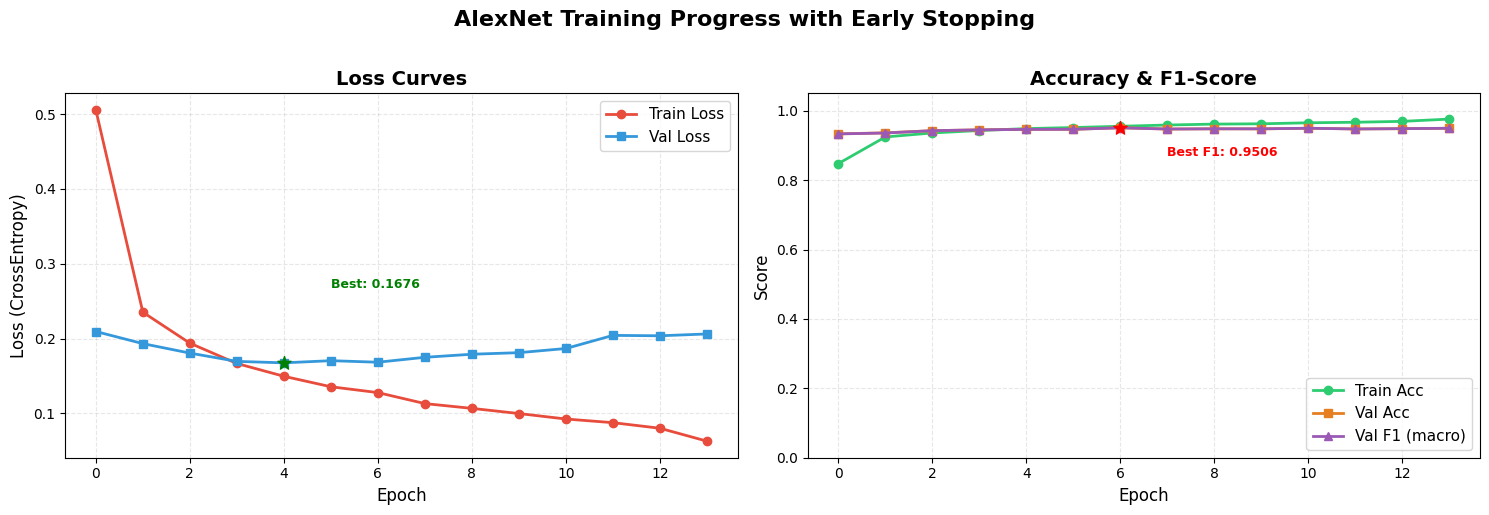


RINGKASAN TRAINING ALEXNET
Total epochs executed   : 14
Best validation loss    : 0.1676 (epoch 4)
Best validation F1      : 0.9506 (epoch 6)
Final train accuracy    : 0.9758
Final val accuracy      : 0.9492
Final val F1            : 0.9494

 Model baik: Gap akurasi = 0.0266 (2.7%)


In [33]:
# Cell 17: Plot kurva training (2 grafik gabungan)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ========== GRAFIK KIRI: LOSS CURVES ==========
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2, markersize=6, color='#e74c3c')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2, markersize=6, color='#3498db')
axes[0].set_title('Loss Curves', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (CrossEntropy)', fontsize=12)
axes[0].legend(fontsize=11, loc='upper right')
axes[0].grid(alpha=0.3, linestyle='--')

# Tambahkan anotasi loss terendah
best_val_loss_epoch = np.argmin(history['val_loss'])
best_val_loss = min(history['val_loss'])
axes[0].scatter(best_val_loss_epoch, best_val_loss, color='green', s=100, zorder=5, marker='*')
axes[0].annotate(f'Best: {best_val_loss:.4f}',
                 xy=(best_val_loss_epoch, best_val_loss),
                 xytext=(best_val_loss_epoch + 1, best_val_loss + 0.1),
                 fontsize=9, fontweight='bold', color='green')

# ========== GRAFIK KANAN: ACCURACY & F1 ==========
axes[1].plot(history['train_acc'], label='Train Acc', marker='o', linewidth=2, markersize=6, color='#2ecc71')
axes[1].plot(history['val_acc'], label='Val Acc', marker='s', linewidth=2, markersize=6, color='#e67e22')
axes[1].plot(history['val_f1'], label='Val F1 (macro)', marker='^', linewidth=2, markersize=6, color='#9b59b6')
axes[1].set_title('Accuracy & F1-Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].legend(fontsize=11, loc='lower right')
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].set_ylim(0, 1.05)

# Tambahkan anotasi F1 terbaik
best_val_f1_epoch = np.argmax(history['val_f1'])
best_val_f1 = max(history['val_f1'])
axes[1].scatter(best_val_f1_epoch, best_val_f1, color='red', s=100, zorder=5, marker='*')
axes[1].annotate(f'Best F1: {best_val_f1:.4f}',
                 xy=(best_val_f1_epoch, best_val_f1),
                 xytext=(best_val_f1_epoch + 1, best_val_f1 - 0.08),
                 fontsize=9, fontweight='bold', color='red')

# ========== JUDUL UTAMA ==========
plt.suptitle('AlexNet Training Progress with Early Stopping',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('alexnet_training_curves_combined.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== PRINT RINGKASAN METRIK TRAINING ==========
print("\n" + "="*60)
print("RINGKASAN TRAINING ALEXNET")
print("="*60)
print(f"Total epochs executed   : {len(history['train_loss'])}")
print(f"Best validation loss    : {best_val_loss:.4f} (epoch {best_val_loss_epoch})")
print(f"Best validation F1      : {best_val_f1:.4f} (epoch {best_val_f1_epoch})")
print(f"Final train accuracy    : {history['train_acc'][-1]:.4f}")
print(f"Final val accuracy      : {history['val_acc'][-1]:.4f}")
print(f"Final val F1            : {history['val_f1'][-1]:.4f}")

# Deteksi overfitting
final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]
gap = final_train_acc - final_val_acc

if gap > 0.1:
    print(f"\n  WARNING: Overfitting terdeteksi!")
    print(f"   Train-Val Accuracy Gap: {gap:.4f} ({gap*100:.1f}%)")
    print(f"   Pertimbangkan: lebih agresif dropout, data augmentation, atau early stopping")
elif gap > 0.05:
    print(f"\n  Overfitting ringan: Gap akurasi = {gap:.4f} ({gap*100:.1f}%)")
else:
    print(f"\n Model baik: Gap akurasi = {gap:.4f} ({gap*100:.1f}%)")
print("="*60)

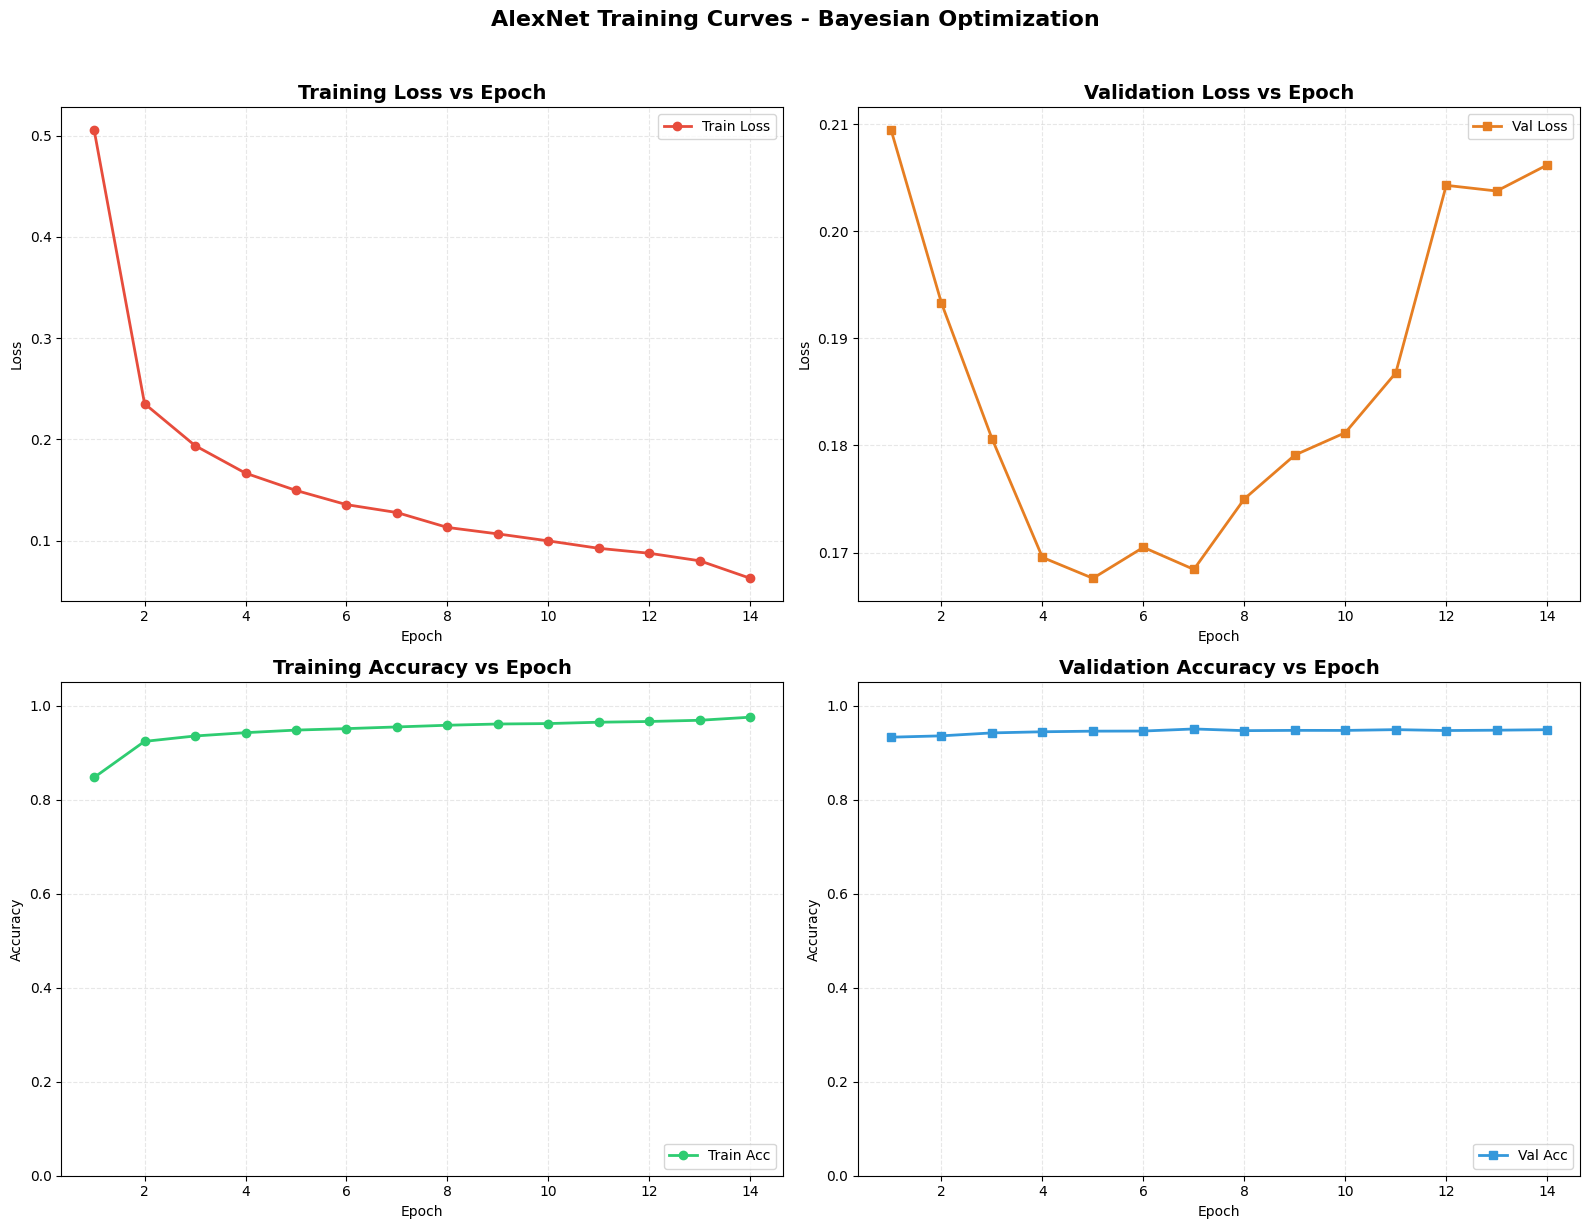

In [34]:
# Cell 17b: Plot 4 grafik terpisah (Training/Validation - Loss/Accuracy)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Training Loss vs Epoch
axes[0, 0].plot(range(1, len(history['train_loss'])+1), history['train_loss'],
                marker='o', linestyle='-', color='#e74c3c', linewidth=2, markersize=6)
axes[0, 0].set_title('Training Loss vs Epoch', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(alpha=0.3, linestyle='--')
axes[0, 0].legend(['Train Loss'], loc='upper right')

# 2. Validation Loss vs Epoch
axes[0, 1].plot(range(1, len(history['val_loss'])+1), history['val_loss'],
                marker='s', linestyle='-', color='#e67e22', linewidth=2, markersize=6)
axes[0, 1].set_title('Validation Loss vs Epoch', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(alpha=0.3, linestyle='--')
axes[0, 1].legend(['Val Loss'], loc='upper right')

# 3. Training Accuracy vs Epoch
axes[1, 0].plot(range(1, len(history['train_acc'])+1), history['train_acc'],
                marker='o', linestyle='-', color='#2ecc71', linewidth=2, markersize=6)
axes[1, 0].set_title('Training Accuracy vs Epoch', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].grid(alpha=0.3, linestyle='--')
axes[1, 0].legend(['Train Acc'], loc='lower right')

# 4. Validation Accuracy vs Epoch
axes[1, 1].plot(range(1, len(history['val_acc'])+1), history['val_acc'],
                marker='s', linestyle='-', color='#3498db', linewidth=2, markersize=6)
axes[1, 1].set_title('Validation Accuracy vs Epoch', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].grid(alpha=0.3, linestyle='--')
axes[1, 1].legend(['Val Acc'], loc='lower right')

plt.suptitle('AlexNet Training Curves - Bayesian Optimization',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('alexnet_training_curves_detailed.png', dpi=300, bbox_inches='tight')  # ← NAMA BEDA
plt.show()

In [28]:
# Cell 18: Evaluasi akhir pada test set
print("\n" + "="*60)
print(" EVALUASI AKHIR PADA TEST SET (AlexNet + Transfer Learning)")
print("="*60)

test_res = evaluate_model(model, test_loader_final, loss_fn)
y_pred = test_res['predictions']
y_true = test_res['labels']

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro')

print(f"\n Hasil Akhir (macro average):")
print(f"   Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision : {precision:.4f}")
print(f"   Recall    : {recall:.4f}")
print(f"   F1-Score  : {f1:.4f}")

print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=LABELS, zero_division=0))


 EVALUASI AKHIR PADA TEST SET (AlexNet + Transfer Learning)

 Hasil Akhir (macro average):
   Accuracy  : 0.9460 (94.60%)
   Precision : 0.9474
   Recall    : 0.9460
   F1-Score  : 0.9461

 Classification Report:
              precision    recall  f1-score   support

           a       0.96      0.93      0.95       327
           b       0.99      0.99      0.99       327
           c       0.99      0.98      0.98       327
           d       0.98      0.99      0.99       327
           e       0.96      0.99      0.98       327
           f       0.96      0.97      0.96       327
           g       0.81      0.84      0.83       327
           h       0.97      0.97      0.97       327
           i       0.76      0.91      0.83       327
           j       0.94      0.89      0.92       327
           k       0.98      0.99      0.98       327
           l       0.93      0.77      0.84       327
           m       0.98      0.98      0.98       327
           n       0.93      

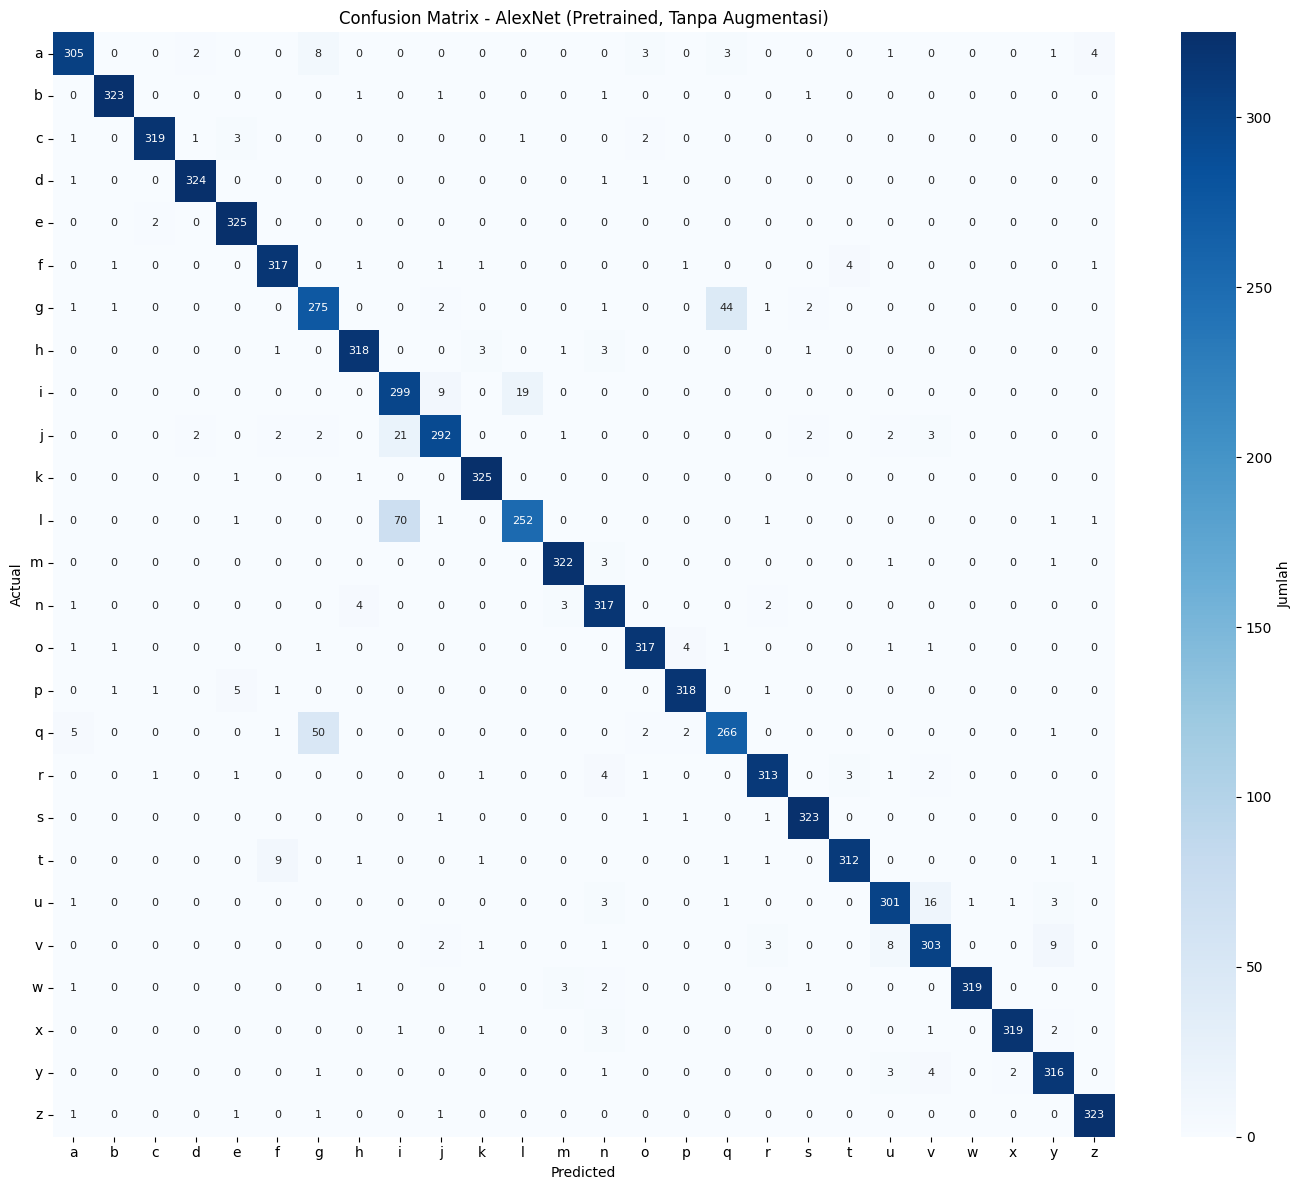

In [29]:
# Cell 19: Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS,
            cbar_kws={'label': 'Jumlah'}, annot_kws={'size': 8})
plt.title('Confusion Matrix - AlexNet (Pretrained, Tanpa Augmentasi)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('alexnet_confusion_matrix.png', dpi=300)
plt.show()

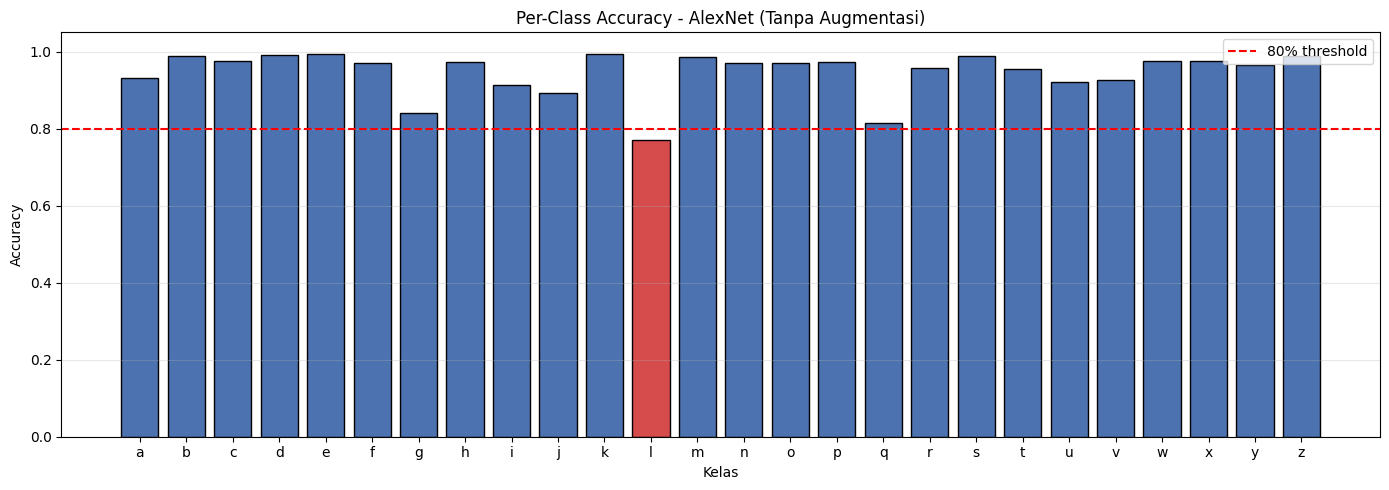

In [30]:
# Cell 20: Akurasi per kelas
per_class_acc = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(14,5))
colors = ['#D64B4B' if a < 0.8 else '#4C72B0' for a in per_class_acc]
plt.bar(LABELS, per_class_acc, color=colors, edgecolor='black')
plt.axhline(0.8, color='red', linestyle='--', label='80% threshold')
plt.title('Per-Class Accuracy - AlexNet (Tanpa Augmentasi)')
plt.xlabel('Kelas')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('alexnet_per_class_accuracy.png', dpi=300)
plt.show()

In [31]:
# Cell 21: Simpan model
model_info = {
    'model_state_dict': model.state_dict(),
    'architecture': 'AlexNet_pretrained',
    'hyperparameters': best_params,
    'class_labels': LABELS,
    'metrics': {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }
}
torch.save(model_info, 'alexnet_bayesian_opt.pth')
print(" Model disimpan sebagai 'alexnet_bayesian_opt.pth'")
print("\n Semua proses selesai.")

 Model disimpan sebagai 'alexnet_bayesian_opt.pth'

 Semua proses selesai.


In [32]:
# Cell 22: Simpan metrics AlexNet ke JSON
import json

cm = confusion_matrix(y_true, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

alexnet_metrics = {
    "model": "AlexNet (Transfer Learning)",
    "architecture": "AlexNet Pretrained ImageNet",
    "hyperparameters": {
        "dropout": best_params['dropout'],
        "optimizer": best_params['optimizer'],
        "learning_rate": best_params['lr'],
        "batch_size": best_params['batch_size'],
        "weight_decay": best_params['weight_decay'],
        "momentum": best_params.get('momentum', None)
    },
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "per_class_accuracy": {LABELS[i]: float(per_class_acc[i]) for i in range(26)},
    "total_parameters": sum(p.numel() for p in model.parameters()),
    "trainable_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
    "training_history": {
        "train_acc": [float(x) for x in history['train_acc']],
        "val_acc": [float(x) for x in history['val_acc']],
        "train_loss": [float(x) for x in history['train_loss']],
        "val_loss": [float(x) for x in history['val_loss']],
        "val_f1": [float(x) for x in history['val_f1']]
    }
}

with open('alexnet_metrics.json', 'w') as f:
    json.dump(alexnet_metrics, f, indent=2)
print(" Metrik AlexNet disimpan ke 'alexnet_metrics.json'")

 Metrik AlexNet disimpan ke 'alexnet_metrics.json'
